In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline




file_path = "Used_Car_Price_Regression_Dataset.xlsx"
df = pd.read_excel(file_path, sheet_name="Car_Data")
df

,Car_ID,Brand_Tier,City_Market,Car_Age_Years,Mileage_KM,Engine_Size_CC,Horsepower_HP,Fuel_Type,Transmission,Previous_Owners,Accident_History,Service_History_Score,Price_USD
0,CAR00001,Mid-range,Sydney,4.3,71744,2740,225,Petrol,Automatic,0,No,5,17260
1,CAR00002,Luxury,New York,0.9,16708,1320,105,Petrol,Automatic,0,No,9,62520
2,CAR00003,Premium,New York,8.3,62956,1920,131,Hybrid,Automatic,1,No,9,25710
3,CAR00004,Mid-range,Islamabad,3.9,71148,1160,77,Petrol,Manual,2,No,5,4690
4,CAR00005,Economy,Dubai,0.8,3234,1810,146,Petrol,Manual,0,Yes,9,14390
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,CAR01996,Mid-range,New York,1.4,27747,1480,98,Petrol,Automatic,2,No,9,21270
1996,CAR01997,Luxury,London,1.0,17691,1410,131,Petrol,Automatic,3,No,5,59040
1997,CAR01998,Economy,London,2.5,45819,2120,195,Petrol,Automatic,1,No,5,14870
1998,CAR01999,Economy,Sydney,9.7,192788,1910,145,Petrol,Automatic,3,No,10,1500


In [54]:
print(df.shape)
print("=====================================")
print(df.isnull().sum())
print("=====================================")
print(df.columns)
print("=====================================")
print(df.info())
print("=====================================")
print(df.describe())
print("=====================================")
print(df.duplicated().sum())

(2000, 13)
Car_ID                   0
Brand_Tier               0
City_Market              0
Car_Age_Years            0
Mileage_KM               0
Engine_Size_CC           0
Horsepower_HP            0
Fuel_Type                0
Transmission             0
Previous_Owners          0
Accident_History         0
Service_History_Score    0
Price_USD                0
dtype: int64
Index(['Car_ID', 'Brand_Tier', 'City_Market', 'Car_Age_Years', 'Mileage_KM',
       'Engine_Size_CC', 'Horsepower_HP', 'Fuel_Type', 'Transmission',
       'Previous_Owners', 'Accident_History', 'Service_History_Score',
       'Price_USD'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Car_ID                 2000 non-null   str    
 1   Brand_Tier             2000 non-null   str    
 2   City_Market            2000 non-null   str    
 3   Car_A

In [55]:
categorical_cols = [
    "Brand_Tier",
    "City_Market",
    "Fuel_Type",
    "Transmission",
    "Accident_History"
]

for col in categorical_cols:
    print("\n==============================")
    print(col)
    print("==============================")
    print(df[col].value_counts())


Brand_Tier
Brand_Tier
Economy      705
Mid-range    700
Premium      398
Luxury       197
Name: count, dtype: int64

City_Market
City_Market
Islamabad    284
Toronto      266
Dubai        262
New York     248
Karachi      245
Lahore       240
London       230
Sydney       225
Name: count, dtype: int64

Fuel_Type
Fuel_Type
Petrol      1109
Diesel       490
Hybrid       265
Electric     136
Name: count, dtype: int64

Transmission
Transmission
Automatic    1284
Manual        716
Name: count, dtype: int64

Accident_History
Accident_History
No     1529
Yes     471
Name: count, dtype: int64


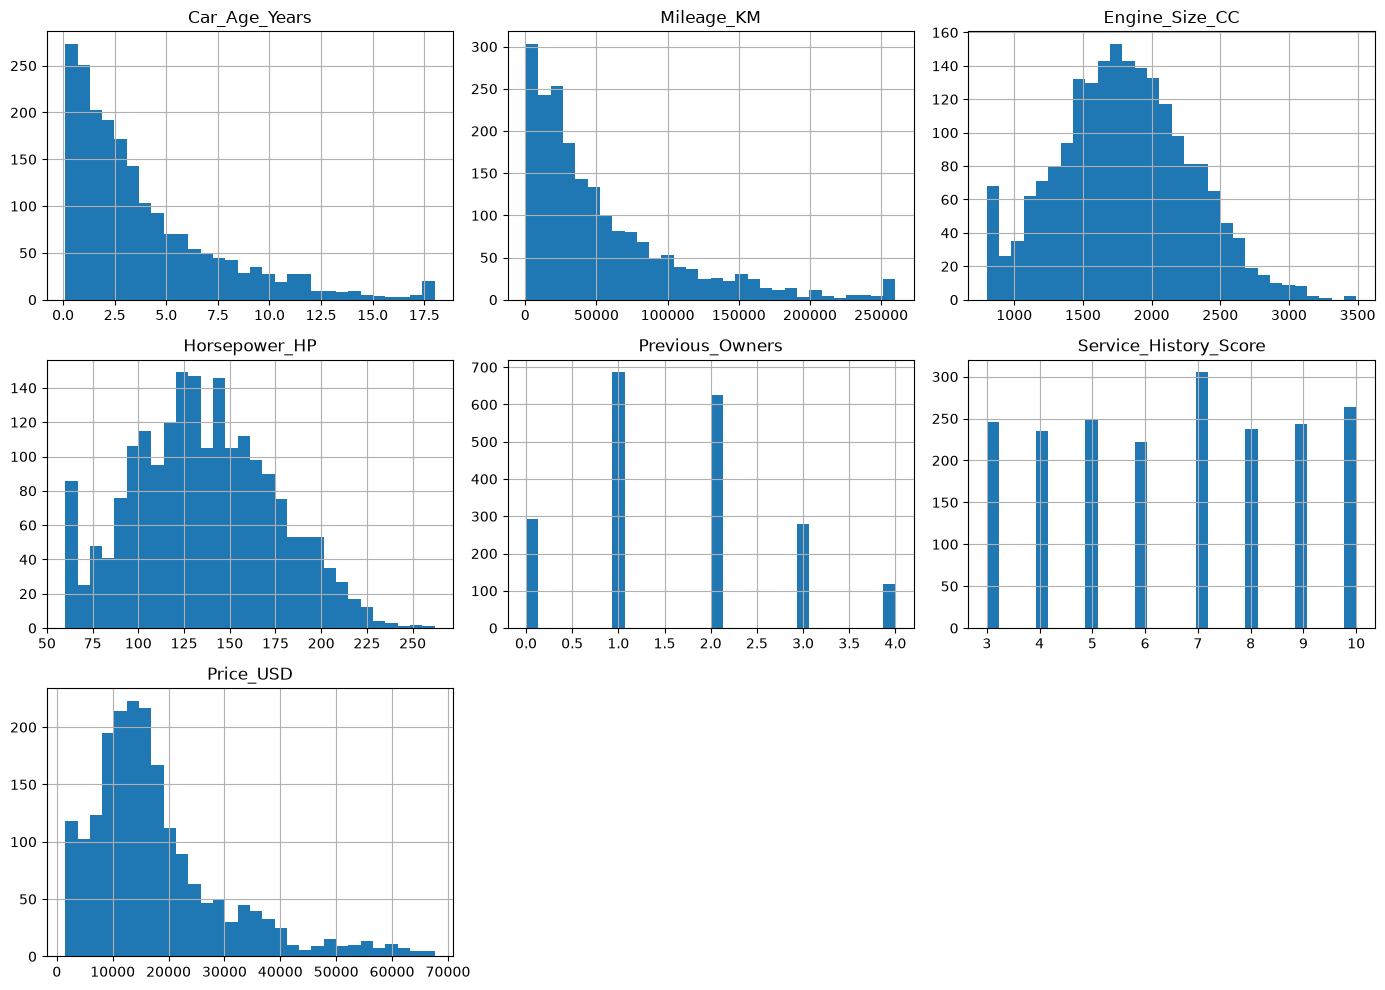

In [56]:
numerical_cols = [
    "Car_Age_Years",
    "Mileage_KM",
    "Engine_Size_CC",
    "Horsepower_HP",
    "Previous_Owners",
    "Service_History_Score",
    "Price_USD"
]

df[numerical_cols].hist(
    figsize=(14, 10),
    bins=30
)

plt.tight_layout()
plt.show()

In [57]:
correlation = df[numerical_cols].corr()

print(correlation["Price_USD"].sort_values(ascending=False))

Price_USD                1.000000
Horsepower_HP            0.067379
Engine_Size_CC           0.062136
Service_History_Score    0.061492
Previous_Owners         -0.067524
Car_Age_Years           -0.409345
Mileage_KM              -0.423553
Name: Price_USD, dtype: float64


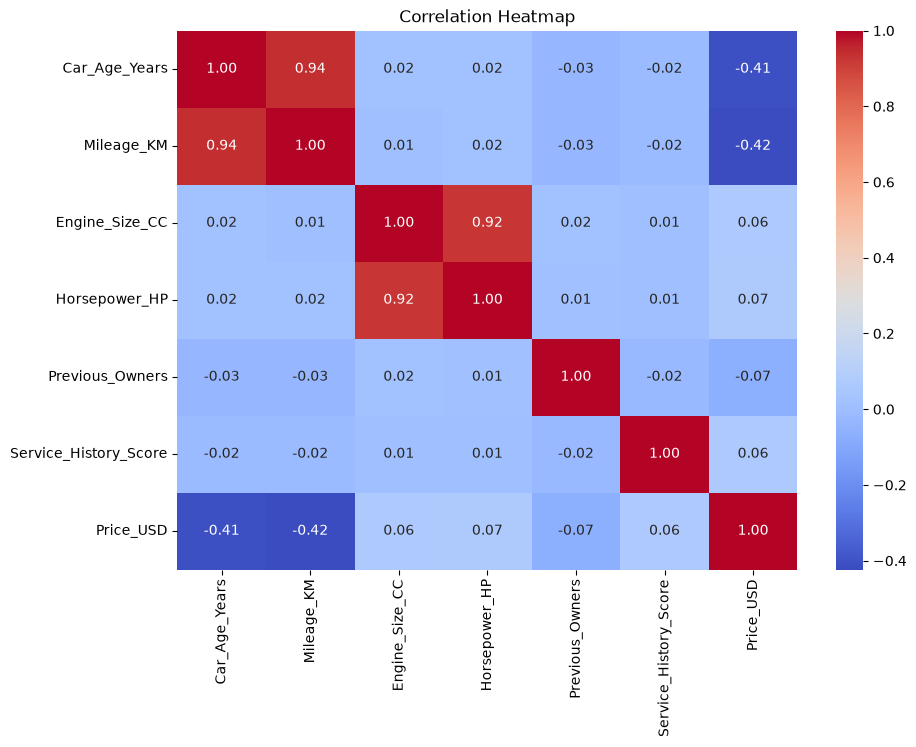

In [58]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

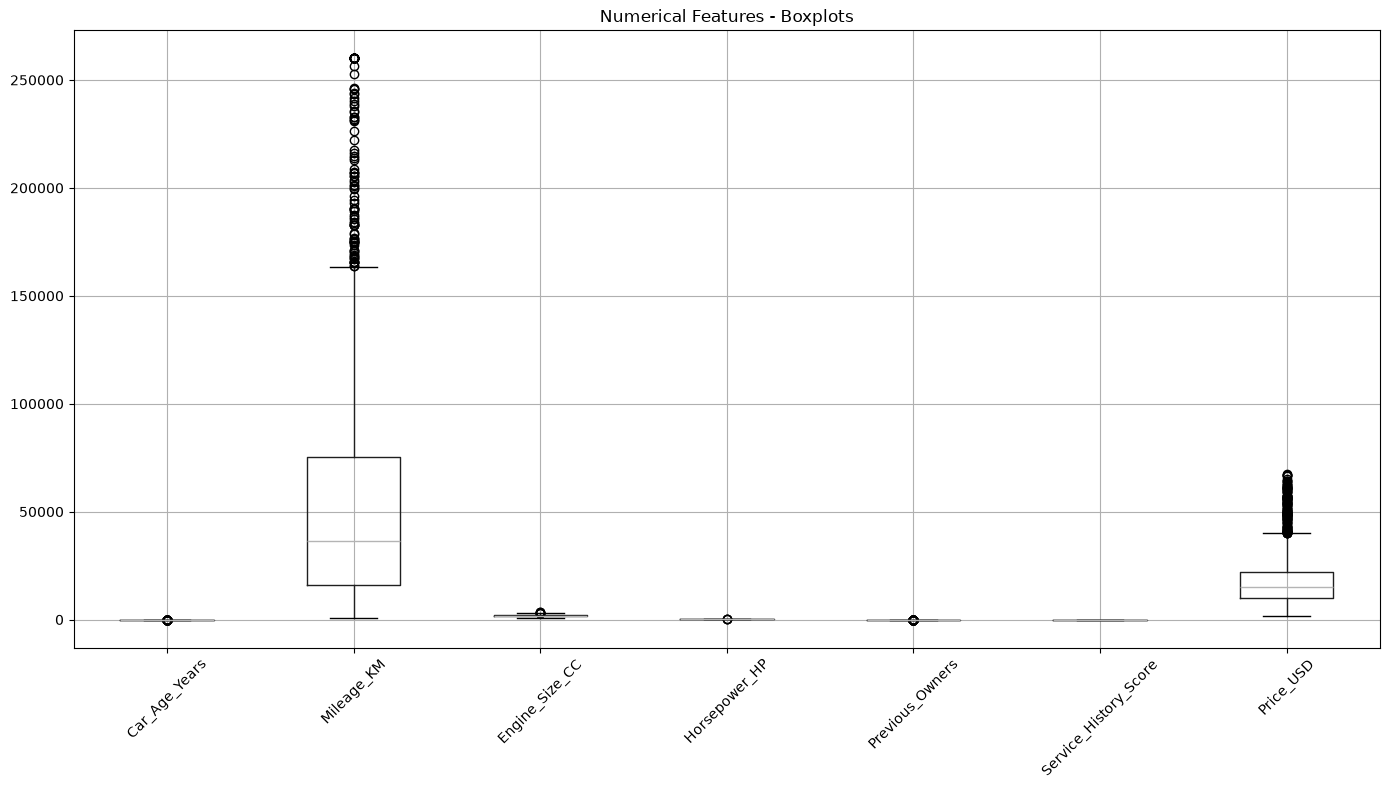

In [59]:
plt.figure(figsize=(14, 8))

df[numerical_cols].boxplot()

plt.xticks(rotation=45)
plt.title("Numerical Features - Boxplots")
plt.tight_layout()

plt.show()

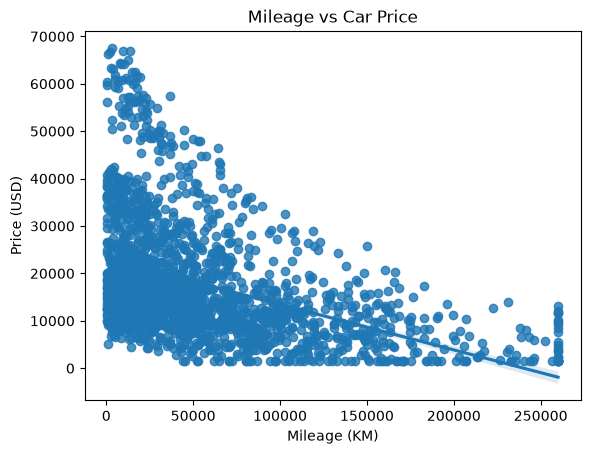

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.regplot(
    data=df,
    x="Mileage_KM",
    y="Price_USD"
)

plt.title("Mileage vs Car Price")
plt.xlabel("Mileage (KM)")
plt.ylabel("Price (USD)")
plt.show()

In [61]:
categorical_cols = [
    "Brand_Tier",
    "City_Market",
    "Fuel_Type",
    "Transmission",
    "Accident_History"
]
numerical_cols = [
    "Car_Age_Years",
    "Mileage_KM",
    "Engine_Size_CC",
    "Horsepower_HP",
    "Previous_Owners",
    "Service_History_Score",
    "Price_USD"
]
print("Categorical columns:")
print(categorical_cols)

print("\nNumerical columns:")
print(numerical_cols)

Categorical columns:
['Brand_Tier', 'City_Market', 'Fuel_Type', 'Transmission', 'Accident_History']

Numerical columns:
['Car_Age_Years', 'Mileage_KM', 'Engine_Size_CC', 'Horsepower_HP', 'Previous_Owners', 'Service_History_Score', 'Price_USD']


In [62]:
X = df.drop(columns=["Car_ID", "Price_USD"])

y = df["Price_USD"]

In [63]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [64]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (1600, 11)
X_test : (400, 11)
y_train: (1600,)
y_test : (400,)


In [65]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols
        )
    ],
    remainder="passthrough"
)

In [66]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

In [67]:
linear_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['Brand_Tier','City_Market','Car_Age_Years',...,'Previous_Owners', 'Accident_History','Service_History_Score']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passe

In [68]:
y_pred = linear_model.predict(X_test)

In [69]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 2719.122230087395


In [70]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE:", rmse)

RMSE: 4163.213146156675


In [71]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R²:", r2)

R²: 0.8972606934529335


In [72]:
from sklearn.tree import DecisionTreeRegressor

decision_tree = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeRegressor(random_state=42))
    ]
)

decision_tree.fit(X_train, y_train)

y_pred_dt = decision_tree.predict(X_test)

mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree")
print("R²:", r2_dt)
print("MAE:", mae_dt)
print("RMSE:", rmse_dt)

Decision Tree
R²: 0.9182459555460222
MAE: 2812.95
RMSE: 3713.769580897555


In [73]:
from sklearn.ensemble import RandomForestRegressor

random_forest = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

random_forest.fit(X_train, y_train)

y_pred_rf = random_forest.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest")
print("R²:", r2_rf)
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)

Random Forest
R²: 0.9621352889958178
MAE: 1925.78825
RMSE: 2527.421377130256


In [74]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "R²": [
        r2,
        r2_dt,
        r2_rf
    ],
    "MAE": [
        mae,
        mae_dt,
        mae_rf
    ],
    "RMSE": [
        rmse,
        rmse_dt,
        rmse_rf
    ]
})

comparison

,Model,R²,MAE,RMSE
0,Linear Regression,0.897261,2719.12223,4163.213146
1,Decision Tree,0.918246,2812.95000,3713.769581
2,Random Forest,0.962135,1925.78825,2527.421377


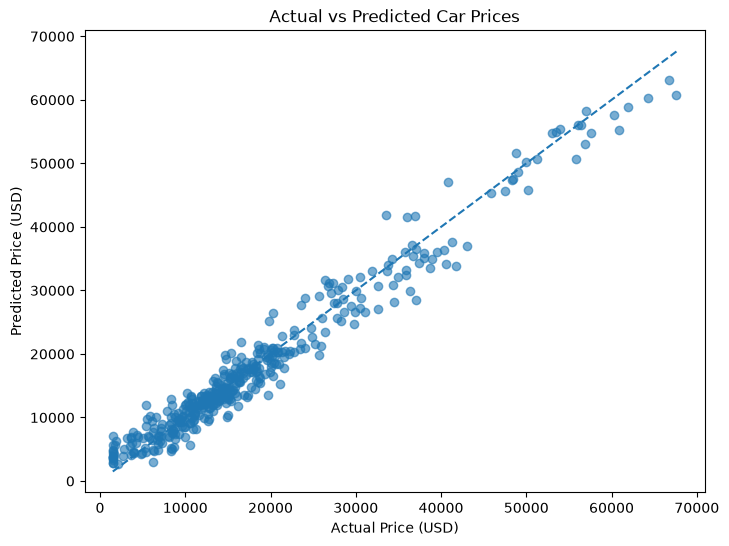

In [75]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_rf, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Price (USD)")
plt.ylabel("Predicted Price (USD)")
plt.title("Actual vs Predicted Car Prices")

plt.show()

In [76]:
best_model = comparison.sort_values(
    by="RMSE",
    ascending=True
).iloc[0]

print("Final Model Evaluation")
print("-----------------------")
print("Model:", best_model["Model"])
print("R²:", round(best_model["R²"], 4))
print("MAE:", round(best_model["MAE"], 2))
print("RMSE:", round(best_model["RMSE"], 2))

print("\nInterpretation:")
print(
    "The regression models were evaluated using R², MAE, and RMSE. "
    "R² measures how much variation in car prices is explained by the model, "
    "while MAE and RMSE measure prediction error. "
    "Higher R² and lower MAE/RMSE indicate better predictive performance."
)

Final Model Evaluation
-----------------------
Model: Random Forest
R²: 0.9621
MAE: 1925.79
RMSE: 2527.42

Interpretation:
The regression models were evaluated using R², MAE, and RMSE. R² measures how much variation in car prices is explained by the model, while MAE and RMSE measure prediction error. Higher R² and lower MAE/RMSE indicate better predictive performance.
